# Beginner's Guide for visualization with Plotly using Titanic Dataset

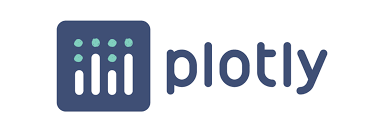

This notebook will guide basic EDAs and Visualization using ***Pandas*** and ***Plotly*** libraries in Python.

In [1]:
#Importing important packages
import pandas as pd
import numpy as np

In [2]:
#Importing Dataset
df_titanic=pd.read_csv('../input/titanic/train.csv')

In [3]:
#Dataset information
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Dataset contains total of *891 entries* out of which *Age*, *Cabin* and *Embarked* are having Null/NaN/missing values.**

In [4]:
#Checking top 5 rows of the dataset
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Visualization with Plotly

**Importing the packages**

In [5]:
#Importing Plotly package
import plotly as py
from plotly.offline import download_plotlyjs,init_notebook_mode,plot,iplot
import plotly.graph_objects as go

In [6]:
#Colorscales in Plotly
import plotly.express as px
from textwrap import wrap

named_colorscales = px.colors.named_colorscales()
print("\n".join(wrap("".join('{:<12}'.format(c) for c in named_colorscales), 96)))

aggrnyl     agsunset    blackbody   bluered     blues       blugrn      bluyl       brwnyl
bugn        bupu        burg        burgyl      cividis     darkmint    electric    emrld
gnbu        greens      greys       hot         inferno     jet         magenta     magma
mint        orrd        oranges     oryel       peach       pinkyl      plasma      plotly3
pubu        pubugn      purd        purp        purples     purpor      rainbow     rdbu
rdpu        redor       reds        sunset      sunsetdark  teal        tealgrn     turbo
viridis     ylgn        ylgnbu      ylorbr      ylorrd      algae       amp         deep
dense       gray        haline      ice         matter      solar       speed       tempo
thermal     turbid      armyrose    brbg        earth       fall        geyser      prgn
piyg        picnic      portland    puor        rdgy        rdylbu      rdylgn      spectral
tealrose    temps       tropic      balance     curl        delta       oxy         edge
hsv     

### Bar Chart for Survival Counts

In [7]:
df_surv = df_titanic.groupby(['Survived'])['PassengerId'].count().reset_index()
df_surv.rename(columns = {'PassengerId':'PassesngerCount'}, inplace = True)
df_surv

,Survived,PassesngerCount
0,0,549
1,1,342


In [8]:
#Pie Chart for Survival Count
fig = {
  "data": [
    {
      "values": df_surv['PassesngerCount'],
      "labels": df_surv['Survived'],
      "name": "Survival Counts",
      "sort": False,
      "marker": {'colors': ['#F38E87', '#2EF91D']},
      "textinfo":"percent",
      "textfont": {'color': '#040504', 'size': 15},

      "hole": .4,
      "type": "pie"
    } ],
    "layout": {
        "title":"Survival Counts",
        "annotations": [
            {
                "font": {
                    "size": 15,
                    "color": '#5A5A5A'
                },
                "showarrow": False,
                "text": "Less than 40% people survived on the Titanic",
                "x": 0.50,
                "y": -0.2
            }
        ]
    }
}

iplot(fig)

### Bar Chart for Survival Counts by Male vs Female

In [9]:
df_g = df_titanic.groupby(['Survived', 'Sex']).size().reset_index()
df_g['percentage'] = df_titanic.groupby(['Survived', 'Sex']).size().groupby(level=1).apply(lambda x: 100 * x / float(x.sum())).values
df_g.columns = ['Survived', 'Sex', 'Counts', 'Percentage']
df_g

,Survived,Sex,Counts,Percentage
0,0,female,81,25.796178
1,0,male,468,81.109185
2,1,female,233,74.203822
3,1,male,109,18.890815


In [10]:
import plotly.graph_objects as go

fig = go.Figure()

x=df_g['Sex']
y=df_g['Percentage']
z=df_g['Survived']

fig.add_trace(go.Bar(x=x, y=y,
                     text=y,
                     textposition='auto',
                     texttemplate="%{y:.1f}",
                     textfont_color="black",
                     textfont_size=11,
                     marker=dict(
                         color = z,
                         colorscale='Tealgrn'
                        ),
                    width=0.2
                    )
             )
fig.update_layout(xaxis_ticks='outside', #Adding Tick Marks on X axis
                  yaxis_ticks='outside', #Adding Tick Marks on Y axis
                  yaxis_ticksuffix = '%', #Adds $ as Prefix
                  paper_bgcolor='rgba(0,0,0,0)',#Transparent Paper BG color
                  plot_bgcolor='rgba(0,0,0,0)', #Transparent Plot BG color
                  #showlegend=True, # Remove Legends
                  title="Survival ratio by Male vs Female",
                  title_x=0.45, #Center title
                  title_yanchor='bottom',#Title Y Axis position
                  title_y=0.88,#Title Y Axis position
                  title_font_size=18,#Title Y Axis position
                  legend=dict(
                      x=0.8,
                      y=0.9,
                      traceorder="normal"
                      ),
                  autosize=False,
                  width=1000,
                  height=450,
                  xaxis=dict(
                            linecolor="#BCCCDC"
                            ),
                  yaxis=dict(
                            linecolor="#BCCCDC"
                            )
                 )
fig.show()

**Females passengers have higher survival ratio compared to Male passengers**

### Distribution of Place of Embarked

In [11]:
df_titanic['Embarked'] = df_titanic['Embarked'].fillna('Unknown')
embarked_points = df_titanic['Embarked'].sort_values(ascending=True).unique()
embarked_points=embarked_points.tolist()
print(embarked_points)
print(type(embarked_points))

total_embarked = df_titanic.groupby(['Embarked'],as_index=True,sort=True).count()['Survived'].to_list()
total_embarked
print(type(total_embarked))

['C', 'Q', 'S', 'Unknown']
<class 'list'>
<class 'list'>


In [12]:
embarked_pie = go.Pie(labels=embarked_points, values=total_embarked)
embarked_pie_layout = go.Layout(title='Embarked')
embarked_pie_fig = go.Figure(data = [embarked_pie], layout=embarked_pie_layout)
iplot(embarked_pie_fig, filename='Titanic Embarked', )

* Most of the passengers onboarded from Southampton (S), followed by Cherbourg (C) and then Queenstown (Q)

### Paasenger Class and their Survival chance

In [13]:
df_pc = df_titanic.groupby(['Survived', 'Pclass']).size().reset_index()
df_pc['percentage'] = df_titanic.groupby(['Survived', 'Pclass']).size().groupby(level=1).apply(lambda x: 100 * x / float(x.sum())).values
df_pc.columns = ['Survived', 'Pclass', 'Counts', 'Percentage']
df_pc

,Survived,Pclass,Counts,Percentage
0,0,1,80,37.037037
1,0,2,97,52.717391
2,0,3,372,75.763747
3,1,1,136,62.962963
4,1,2,87,47.282609
5,1,3,119,24.236253


**Class 1 passengers had highest survival chances**

In [14]:
import plotly.graph_objects as go

fig = go.Figure()

x=df_pc['Pclass']
y=df_pc['Percentage']
z=df_pc['Survived']

fig.add_trace(go.Bar(x=x, y=y,
                     text=y,
                     textposition='auto',
                     texttemplate="%{y:.1f}",
                     textfont_color="black",
                     textfont_size=11,
                     marker=dict(
                         color = z,
                         colorscale='Tealgrn'
                        ),
                    width=0.2
                    )
             )
fig.update_layout(xaxis_ticks='outside', #Adding Tick Marks on X axis
                  yaxis_ticks='outside', #Adding Tick Marks on Y axis
                  yaxis_ticksuffix = '%', #Adds $ as Prefix
                  paper_bgcolor='rgba(0,0,0,0)',#Transparent Paper BG color
                  plot_bgcolor='rgba(0,0,0,0)', #Transparent Plot BG color
                  #showlegend=True, # Remove Legends
                  title="Survival ratio by Passenger Class",
                  title_x=0.45, #Center title
                  title_yanchor='bottom',#Title Y Axis position
                  title_y=0.88,#Title Y Axis position
                  title_font_size=18,#Title Y Axis position
                  legend=dict(
                      x=0.8,
                      y=0.9,
                      traceorder="normal"
                      ),
                  autosize=False,
                  width=1000,
                  height=450,
                  xaxis=dict(
                            linecolor="#BCCCDC"
                            ),
                  yaxis=dict(
                            linecolor="#BCCCDC"
                            )
                 )
fig.show()

**I Keep updating this space with more visualizations, please keep visiting here!**